In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report, precision_recall_curve, recall_score
from sklearn.model_selection import learning_curve, GridSearchCV, train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

In [58]:
dataset_path = "C:/Users/tamer/.cache/kagglehub/datasets/einsteindata4u/covid19/versions/7/dataset.xlsx"
df = pd.read_excel(dataset_path)
# repartir avec le dataset original pour le pré-processing

In [3]:
pd.set_option("display.max_row",111)
pd.set_option("display.max_column",111)

# 1) Exploration du dataset

In [ ]:
df.head()

float64    70
object     37
int64       4
Name: count, dtype: int64


<Axes: ylabel='count'>

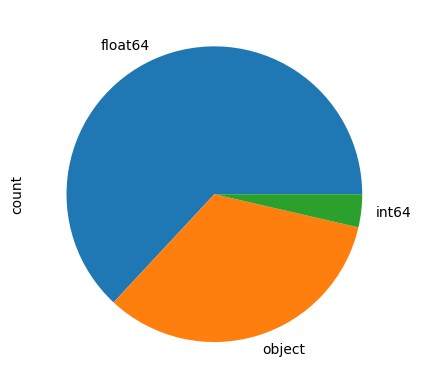

In [62]:
print(df.dtypes.value_counts())
df.dtypes.value_counts().plot.pie() # => pie chart

### Données manquantes

<Axes: >

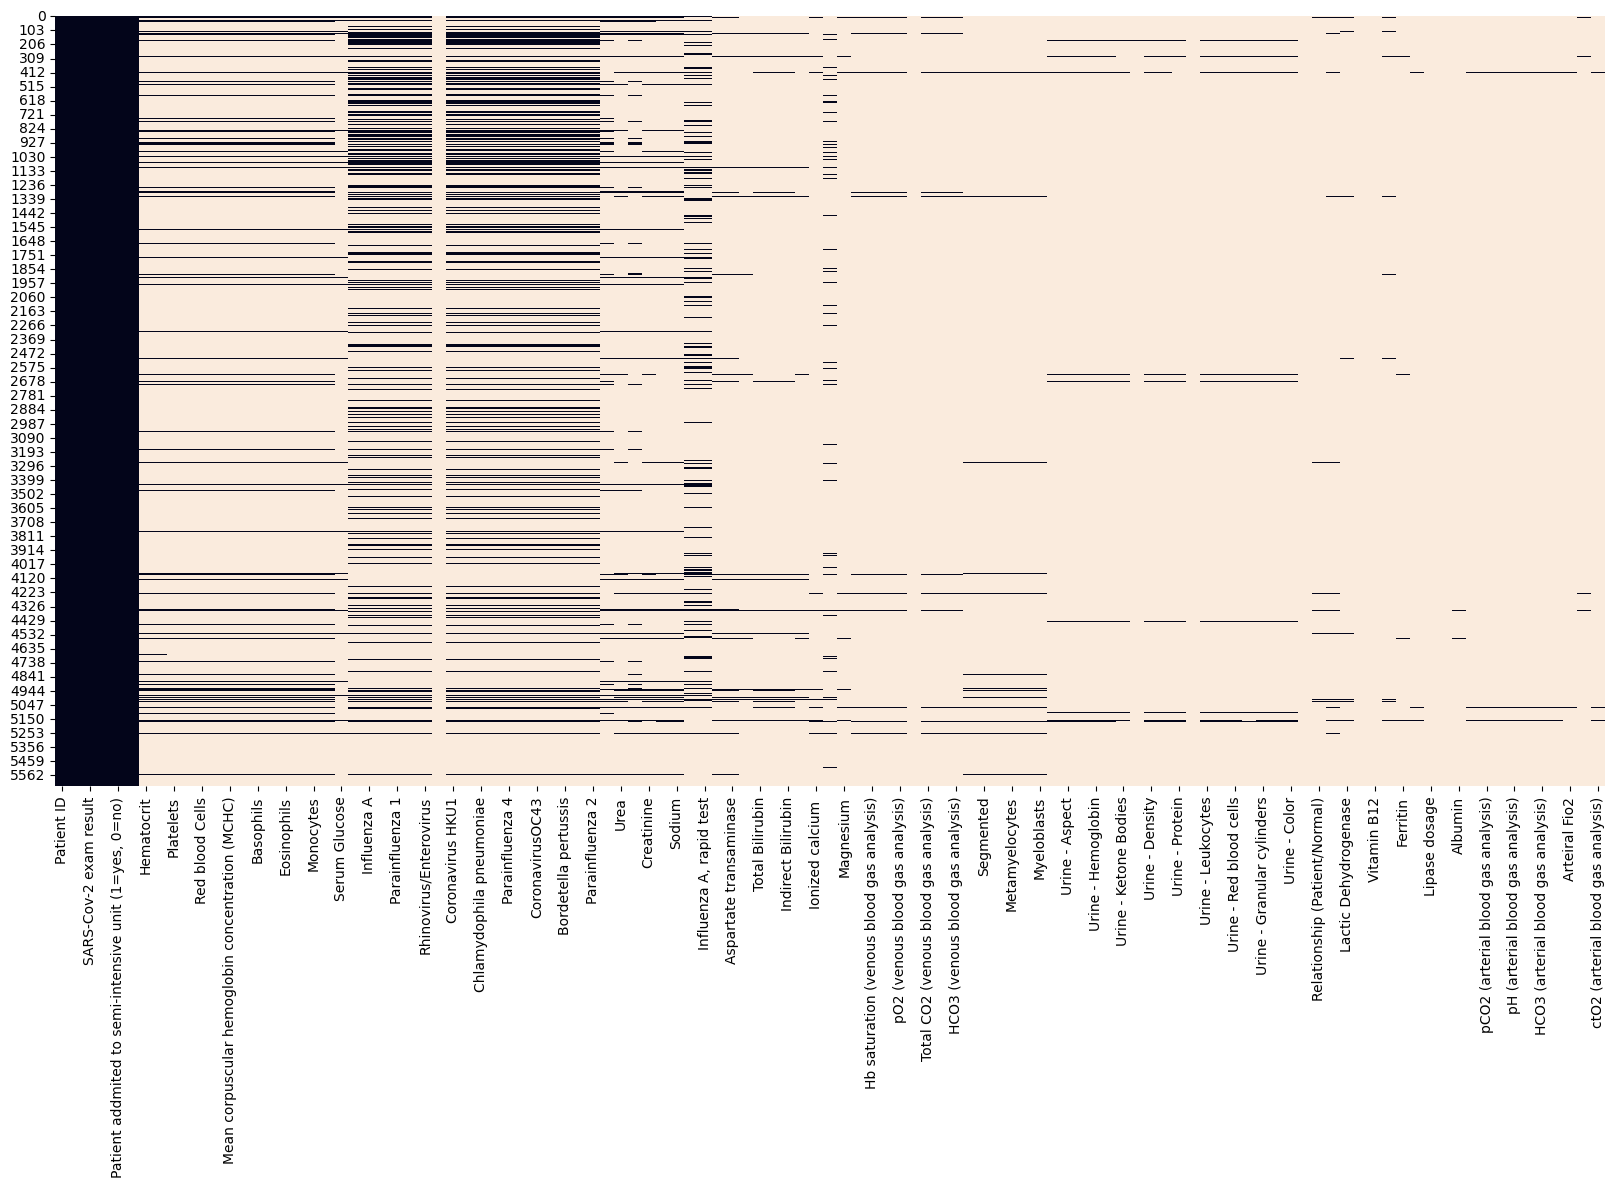

In [63]:
plt.figure(figsize=(20,10))
sns.heatmap(df.isna(), cbar = False)

In [ ]:
# Pourcentage de missing value dans chaque colone
(df.isna().sum()/df.shape[0]).sort_values() 

### Variables continues

In [ ]:
# représentation graphiques des var continues
for col in df.select_dtypes('float'):
    plt.figure()
    sns.displot(df[col])

### Variables qualitatives

In [ ]:
for col in df.select_dtypes('object'):
    print(f'{col:-<50} {df[col].unique()}')

### Analyse des relations entre variables : voir video

### Selection des colonnes d'intérêt

In [4]:
missing_rate = df.isna().sum()/df.shape[0]
blood_cols = list(df.columns[(missing_rate < 0.9) & (missing_rate > 0.88)])
viral_cols = list(df.columns[(missing_rate < 0.80) & (missing_rate > 0.75)])
key_cols = ['Patient age quantile', 'SARS-Cov-2 exam result']

In [5]:
df = df[blood_cols + viral_cols + key_cols]

# 2) Traintest, Nettoyage, Encodage, modèles préliminaires

### Train test

In [6]:
trainset, testset = train_test_split(df, test_size = 0.2, random_state=0)

In [7]:
trainset['SARS-Cov-2 exam result'].value_counts() # vérifier le bon split des data, homgène entre les 2 classes à discriminer

SARS-Cov-2 exam result
negative    4068
positive     447
Name: count, dtype: int64

### Préprecessing

In [8]:
# Créer une fonction pour encoder le dataset, qu'on pourra réutiliser ensuite sur le testset

def encodage(df):
    code = {
    'positive' : 1,
    'negative' : 0,
    'detected' : 1,
    'not_detected' : 0
}
# Appliquer ce dictionnaire aux colonnes du dataset, avec la fonction map
    for col in df.select_dtypes('object'):
        df[col] = df[col].map(code)

    return df


def inputation(df):
    return df.dropna(axis=0)


# Créer une fonction qui performe le préprocessing, et créé les variables X_test et y_test
def preprocessing(df):
    df = encodage(df)
    df = inputation(df)

    X = df.drop('SARS-Cov-2 exam result', axis =1)
    y = df['SARS-Cov-2 exam result']

    # compter le nombre d'échantillons restants dans le dataset après avoir été inputé
    print(y.value_counts())

    return X, y

In [9]:
X_train, y_train = preprocessing(trainset)
X_test, y_test = preprocessing(testset)

SARS-Cov-2 exam result
0    258
1     38
Name: count, dtype: int64
SARS-Cov-2 exam result
0    54
1    12
Name: count, dtype: int64


### Modelisation préliminaire

In [10]:
#model = DecisionTreeClassifier(random_state=0)
model = RandomForestClassifier(random_state=0)
#model = make_pipeline(SelectKBest(f_classif, k=5), RandomForestClassifier(random_state=0))

### Procédure d'évaluation

In [11]:
# On veut d'abord créer une fonction basique qui va grossièrement evaluer notre data et permettre d'identifier les points à améliorer
# Génère confusion matrix et classification report : metrics de base du modèle (y_test vs y_pred)
# Génère learning curve : evalue l'over/underfit, et l'influence du nombre de samples 

def evaluation(model):
    model.fit(X_train, y_train)
    ypred = model.predict(X_test)

    print(confusion_matrix(y_test, ypred))
    print(classification_report(y_test, ypred))

    #evaluation du modèle en fonction du nombre de samples, basé sur le f1 score
    N, train_score, val_score = learning_curve(model, X_train, y_train, cv=4, scoring='f1', train_sizes=np.linspace(0.1, 1, 10))

    plt.figure(figsize=(12,8))
    # on prend les .means de chaque round de cv. cv = 4 <=> on sépare le dataset en 4 et prend 3 part = train 1 part = test, puis on échange
    plt.plot(N, train_score.mean(axis=1), label = 'train score')
    plt.plot(N, val_score.mean(axis=1), label = 'val score')
    plt.legend()

[[54  0]
 [11  1]]
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        54
           1       1.00      0.08      0.15        12

    accuracy                           0.83        66
   macro avg       0.92      0.54      0.53        66
weighted avg       0.86      0.83      0.77        66



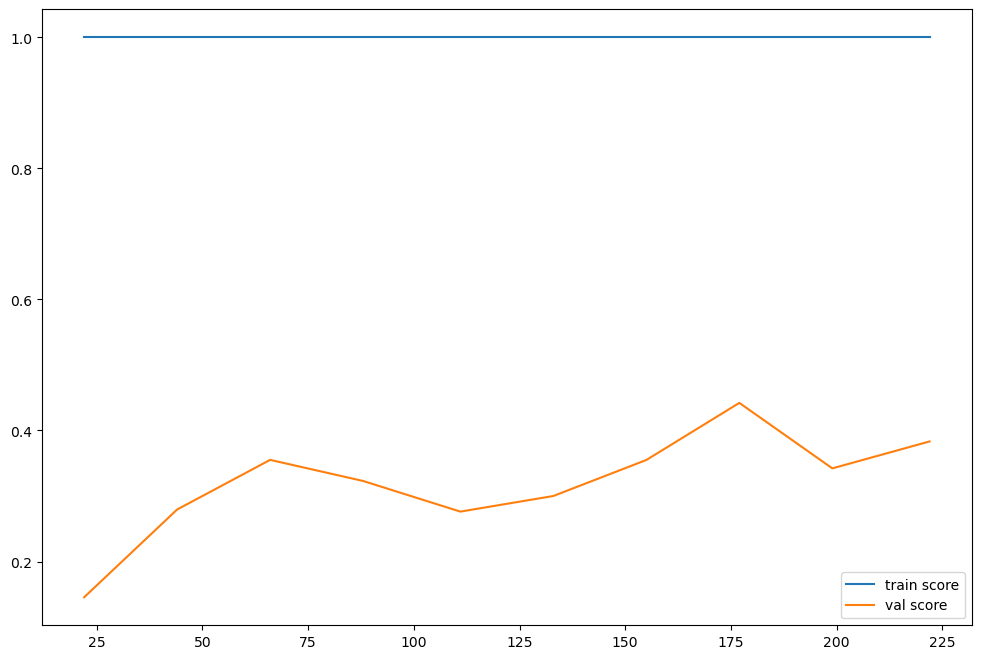

In [12]:
np.seterr(divide='ignore', invalid='ignore')
evaluation(model)
# confusion matrix : 
# recall = pourcentage de bonne identification
# Le plot permet de comprendre si dataset underfit-overfit
# pour lutter contre overfit : augmenter samples ou réduire les vars

<Figure size 6000x1200 with 0 Axes>

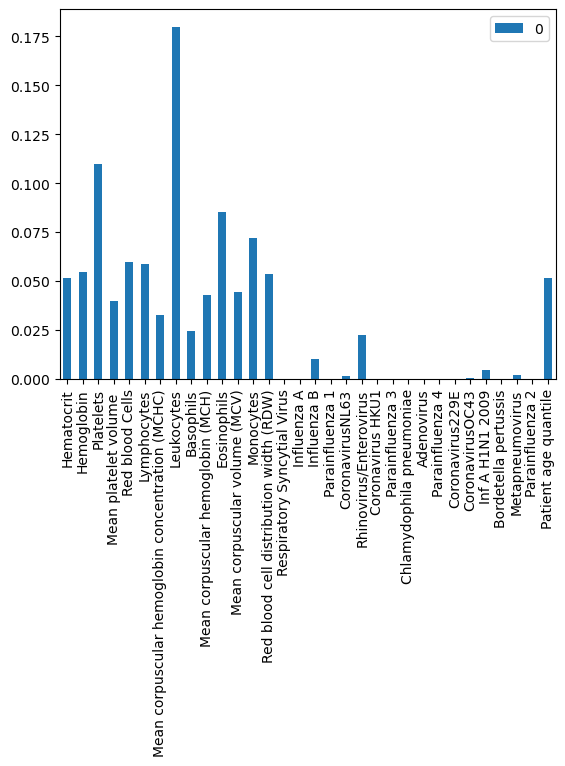

<Figure size 6000x1200 with 0 Axes>

In [13]:
# Var selection
pd.DataFrame(model.feature_importances_, index=X_train.columns).plot.bar()
plt.figure(figsize=(60,12))

# 3) Optimisation du modèle

### Evaluation de plusieurs classificateurs

In [14]:
# Création du pipeline de préprocessing
preprocessor = make_pipeline(PolynomialFeatures(2, include_bias = False), SelectKBest(f_classif, k=10))

In [15]:
RandomForest = make_pipeline(preprocessor, RandomForestClassifier(random_state = 0))
AdaBoost = make_pipeline(preprocessor, AdaBoostClassifier(random_state = 0))
SVM = make_pipeline(preprocessor, StandardScaler(), SVC(random_state = 0))
KNN = make_pipeline(preprocessor, StandardScaler(), KNeighborsClassifier())
# Note : SVM and KNN need standardization 

In [23]:
dict_of_models = {'RandomForest' : RandomForest, 
                  'AdaBoost' : AdaBoost, 
                  'SVM' : SVM, 
                  'KNN' : KNN}

In [ ]:
for name, model in list_of_models.items():
    print(name)
    evaluation(model)

### Optimisation des meilleurs modèles

In [27]:
SVM

Pipeline(steps=[('pipeline',
                 Pipeline(steps=[('polynomialfeatures',
                                  PolynomialFeatures(include_bias=False)),
                                 ('selectkbest', SelectKBest())])),
                ('standardscaler', StandardScaler()),
                ('svc', SVC(random_state=0))])

In [36]:
hyper_params = {'svc__gamma': [1e-3, 1e-4],
                'svc__C' : [1, 10, 100, 1000],
               'pipeline__polynomialfeatures__degree' : [2, 3, 4],
               'pipeline__selectkbest__k' : range(4, 100)}

In [ ]:
# grid = GridSearchCV(SVM, hyper_params, scoring='recall', cv=4) # regular grid search
grid = RandomizedSearchCV(SVM, hyper_params, scoring='recall', cv=4, n_iter = 40) # après prélimnary identification des best params, on peut relancer la random search avec des paramètres plus ciblés, et narrow down de plus en plus


grid.fit(X_train, y_train)
print(grid.best_params_)

y_pred = grid.predict(X_test)
print(classification_report(y_test, y_pred))

In [ ]:
evaluation(grid.best_estimator_)

In [ ]:
# Alternative à GridSearchCV si beaucoup de paramètres à tester : 

### Precision recall curve

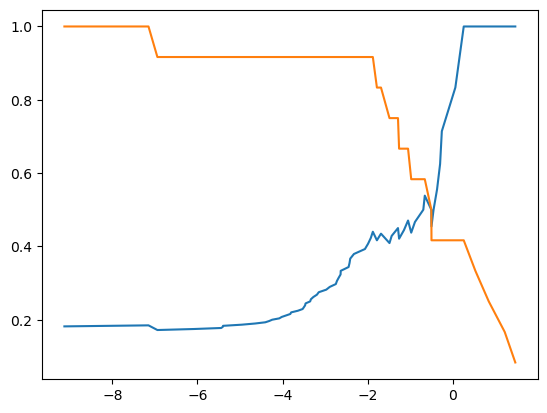

In [48]:
precision, recall, threshold = precision_recall_curve(y_test, grid.best_estimator_.decision_function(X_test))

plt.plot(threshold, precision[:-1], label='precision')
plt.plot(threshold, recall[:-1], label='recall')

### Fonction de prédiction

In [49]:
def model_final(model, X, threshold=0):
    return model.decision_function(X) > threshold

In [52]:
y_pred = model_final(grid.best_estimator_, X_test, threshold = -1)

In [56]:
f1_score(y_test, y_pred)
recall_score(y_test, y_pred)

0.5833333333333334